# LDA

In [39]:
import warnings 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df=pd.read_csv(r"C:\Users\Windows\ML_Theory\Wine.csv")

In [43]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [45]:
df.Customer_Segment.unique()

array([1, 2, 3], dtype=int64)

In [51]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [53]:
x=df.iloc[:, :-1].values
y=df.iloc[:, -1].values


In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=0)


In [57]:
from sklearn.linear_model import LogisticRegression
reg=LogisticRegression()
reg.fit(x_train, y_train)

LogisticRegression()

In [63]:
y_pred=reg.predict(x_test)
y_pred

array([1, 3, 2, 1, 2, 2, 1, 3, 2, 2, 3, 3, 1, 2, 3, 2, 1, 1, 3, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 3, 1, 1, 2, 1, 1, 1], dtype=int64)

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix
cm=confusion_matrix(y_pred, y_test)
cm

array([[13,  1,  0],
       [ 1, 14,  0],
       [ 0,  1,  6]], dtype=int64)

<Axes: >

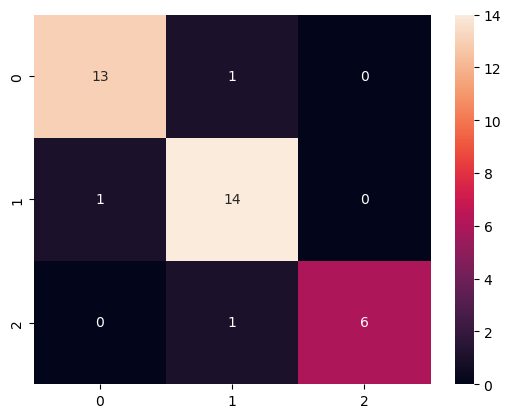

In [67]:
sns.heatmap(cm, annot=True,)

# After a Dimensionality Reduction LDA

In [70]:
from sklearn.preprocessing import StandardScaler
sd=StandardScaler()

sd

StandardScaler()

In [72]:
x_train=sd.fit_transform(x_train)
x_test=sd.transform(x_test)

In [74]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
lda=lda(n_components=2)
lda

LinearDiscriminantAnalysis(n_components=2)

In [76]:
x_train=lda.fit_transform(x_train, y_train)
x_test=lda.transform(x_test)

In [78]:
variance=lda.explained_variance_ratio_
variance

array([0.73931691, 0.26068309])

In [80]:
from sklearn.linear_model import LogisticRegression
re=LogisticRegression()
re.fit(x_train, y_train)

LogisticRegression()

In [82]:
y_pr=re.predict(x_test)

In [84]:
from sklearn.metrics import accuracy_score, confusion_matrix
cm=confusion_matrix(y_pr, y_test)
cm

array([[14,  0,  0],
       [ 0, 16,  0],
       [ 0,  0,  6]], dtype=int64)

<Axes: >

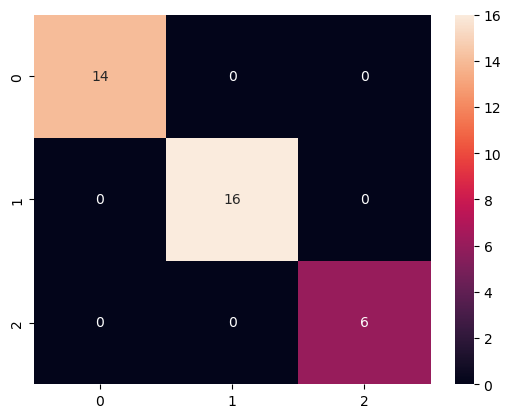

In [86]:
sns.heatmap(cm, annot=True,)

In [88]:
accuracy_score(y_pr,y_test)

1.0

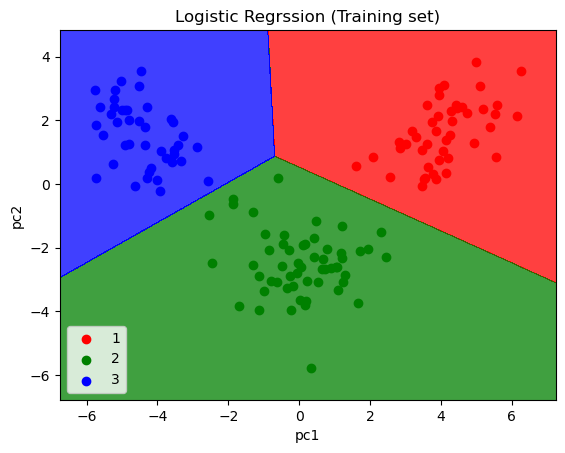

In [90]:
from matplotlib.colors import ListedColormap
x_set, y_set=x_train, y_train
x1, x2=np.meshgrid(np.arange(start=x_set[:, 0].min()-1, stop=x_set[:, 0].max() + 1, step = 0.01), 
                   np.arange(start=x_set[:, 1].min()-1, stop=x_set[:, 1].max() + 1, step = 0.01))

plt.contourf(x1, x2, re.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape), alpha=0.75, cmap=ListedColormap(('red', 'green', 'blue')))

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
for i , j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], 
               c=ListedColormap(('red', 'green', 'blue'))(i), label=j)

plt.title('Logistic Regrssion (Training set)')
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.legend()
plt.show()